In [28]:
## Parallel programming imports
import ipyparallel as ipp
from mpi4py import MPI
cluster = ipp.Cluster(engines = "mpi", n = 9)
rc = cluster.start_and_connect_sync()

Starting 9 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/9 [00:00<?, ?engine/s]

In [29]:
%%px

import importlib.util

if importlib.util.find_spec("petsc4py") is not None:
    import dolfinx

    if not dolfinx.has_petsc:
        print("This demo requires DOLFINx to be compiled with PETSc enabled.")
        exit(0)
    from petsc4py.PETSc import ScalarType  # type: ignore
else:
    print("This demo requires petsc4py.")
    exit(0)

# +
import sys
import time

import numpy as np
import petsc4py
from petsc4py import PETSc
import gmsh
import matplotlib.pyplot as plt
import pyvista


import ufl
from ufl import (FacetNormal, Measure, SpatialCoordinate, TestFunction, TrialFunction, 
                 div, dot, dx, grad, inner, lhs, rhs, system)

from dolfinx import fem, io, mesh, plot, la
from dolfinx.fem import (Constant,  Function, functionspace, assemble_scalar, 
                         dirichletbc, form, locate_dofs_topological, Function)
import dolfinx.fem.petsc as petsc
from dolfinx.fem.petsc import LinearProblem
from dolfinx.io import (gmshio, XDMFFile, VTXWriter)
from dolfinx.plot import vtk_mesh
from dolfinx.geometry import bb_tree, compute_colliding_cells, compute_collisions_points
from dolfinx.mesh import create_unit_square, locate_entities, meshtags
from dolfinx.graph import partitioner_scotch

petsc4py.init(sys.argv)

In [30]:
%%px

gmsh.initialize()
gmsh.open("BoxMesh.geo")
model = gmsh.model
model_name = model.getCurrent()

#partitioner = dolfinx.mesh.create_cell_partitioner(partitioner_scotch())
partitioner = mesh.create_cell_partitioner(mesh.GhostMode.shared_facet)
umesh, ucell_tags, ufacet_tags = gmshio.model_to_mesh( 
    model, 
    MPI.COMM_WORLD, 
    rank = 0,
    gdim = 3, 
    partitioner = partitioner 
)
gmsh.finalize() 

gmsh.initialize()
gmsh.open("BoxMesh_210.geo")
model = gmsh.model
model_name = model.getCurrent()

u2mesh, u2cell_tags, u2facet_tags = gmshio.model_to_mesh(
    model, 
    MPI.COMM_WORLD, 
    rank = 0,
    gdim = 3, 
    partitioner = partitioner 
)
gmsh.finalize() 


umesh.topology.create_connectivity(umesh.topology.dim-1, umesh.topology.dim)
u2mesh.topology.create_connectivity(u2mesh.topology.dim-1, u2mesh.topology.dim)
V1 = fem.functionspace(umesh, ("Lagrange", 1))
V2 = fem.functionspace(u2mesh, ("Lagrange", 1))

top_marker, bottom_marker, sides_marker = 13, 14, 15

print(len(ucell_tags.values), "umesh DOFs for this process")
print(len(u2cell_tags.values), "u2mesh DOFs for this process")

[stdout:0] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.000846545s, CPU 0.001019s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.0029311s, CPU 0.0028s)
Info    : M

[stdout:1] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.000972816s, CPU 0.001267s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.0037267s, CPU 0.003718s)
Info    :

[stdout:2] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.00102125s, CPU 0.001293s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.00383362s, CPU 0.00385s)
Info    : 

[stdout:3] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.0010109s, CPU 0.001273s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.00373392s, CPU 0.003751s)
Info    : 

[stdout:4] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.00119565s, CPU 0s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.00269206s, CPU 0s)
Info    : Meshing 3D...

...

[stderr:6] Warning : Boolean fragments skipped - too few arguments


[stderr:0] Warning : Boolean fragments skipped - too few arguments


[stderr:3] Warning : Boolean fragments skipped - too few arguments


[stderr:5] Warning : Boolean fragments skipped - too few arguments


[stderr:4] Warning : Boolean fragments skipped - too few arguments


%%px
# from Jokken's tutorial: https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html 
# 1: sides  
# 2: heatplate 
# 3: laser 
boundaries = [(sides_marker, lambda x: np.isclose(x[0], 0.0) | np.isclose(x[0], 1.0) | np.isclose(x[1], 0.0) | np.isclose(x[1], 1.0)),
              (bottom_marker, lambda x: np.isclose(x[2], 0.0)),
              (top_marker, lambda x: np.isclose(x[2], z_max))]

facet_indices, facet_markers = [], []
fdim = umesh.topology.dim - 1
for (marker, locator) in boundaries:
    facets = locate_entities(msh, fdim, locator)
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32)
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(msh, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets])

In [87]:
%%px

#create custom ds for where Neumann BC needs to be applied 
ds1 = Measure("ds", domain=umesh, subdomain_data=ufacet_tags) # "exterior_facet" instead of "ds"?
ds2 = Measure("ds", domain=u2mesh, subdomain_data=u2facet_tags)

tdim = umesh.topology.dim
fdim = umesh.topology.dim - 1

In [ ]:
%%px
# let's go: transient heat equation
time_smoothing = 1000.0

t = 0.0
t_end = 250 # [s]
delta_t = 0.1 # [s] 
n_timesteps = int(t_end/delta_t) + 1

# Define the problem parameters
rho = 4700.0 #[kg/m^3]
cp = 500.0 #[J/(kg*K)]
k = 20.0 #[W/(m*K)]

h_bulk_powder = 10.0 # [W/(m^2*K)]

T_heatplate = 500.0 # [K]
q_powder = h_bulk_powder * 300.0 # [W/m^2] where 300 is the temperature difference between powder and part

T_initial = 600.0 # [K]

In [54]:
%%px 

# input parameters
v_laser = 1.0 # [m/s] https://www.sciencedirect.com/science/article/pii/S2238785424027923
P_laser = 250.0 # [W]
h_hatch_um = 100.0 # [um]
t_interlayer = 10.0 # [s]

n_layers_lumped = 1

# intermediate values 
h_hatch = h_hatch_um * 1e-6 # [m]
n_hatches = 0.1/h_hatch 
length_hatch = 0.1 # [m]
t_true = n_hatches * length_hatch / v_laser # [s]
ved = P_laser/(v_laser * h_hatch * t_true)

t_true_scanning = 0.1**2 / (h_hatch * v_laser) # [s]
E_tot_layer = P_laser * t_true_scanning # [J] 
E_tot = n_layers_lumped * E_tot_layer # [J]
t_tot = n_layers_lumped * (t_true + t_interlayer) # [s]
t_per_layer = t_true_scanning + t_interlayer # [s]

# important values: 
q_laserpower = time_smoothing * P_laser / 0.1**2 # [W/m^2]
t_adapt_scanning = t_true_scanning / time_smoothing # [s]

# short stability value 
stability_value = delta_t * k / (rho * cp * (0.1/40))
#print("Stability value: ", stability_value, "; is small?")

In [122]:
%%px

# Define the test function and trial function
T1 = TrialFunction(V1)
T2 = TrialFunction(V2)
v1 = TestFunction(V1)
v2 = TestFunction(V2)
T_n1 = Function(V1) # previous time step
T_n2 = Function(V2) # previous time step
#T_heatplate1 = Function(V1) # heatplate temperature
#T_heatplate2 = Function(V2) # heatplate temperature
x1 = SpatialCoordinate(umesh)
x2 = SpatialCoordinate(u2mesh)
n1 = FacetNormal(umesh)
n2 = FacetNormal(u2mesh)

# Define the variational problem
F_list1 = []
F_list2 = []

F1_1 = rho * cp * T1 * v1 * dx # goes into a 
F2_1 = delta_t * k / 2.0 * inner(grad(T1), grad(v1)) * dx # goes into a 
F3_1 = - rho * cp * T_n1 * v1 * dx # goes into L 
F4_1 = delta_t * k / 2.0 * inner(grad(T_n1), grad(v1)) * dx 

F_list1.append(F1_1)
F_list1.append(F2_1)
F_list1.append(F3_1)
F_list1.append(F4_1)

F1_2 = rho * cp * T2 * v2 * dx # goes into a
F2_2 = delta_t * k / 2.0 * inner(grad(T2), grad(v2)) * dx # goes into a
F3_2 = - rho * cp * T_n2 * v2 * dx # goes into L
F4_2 = delta_t * k / 2.0 * inner(grad(T_n2), grad(v2)) * dx

F_list2.append(F1_2)
F_list2.append(F2_2)
F_list2.append(F3_2)
F_list2.append(F4_2)

In [123]:
%%px 

def q_laser_function(t): 
    cycle_index = int(t // t_per_layer)

    if cycle_index >= n_layers_lumped: 
        return q_powder*delta_t
    t_in_cycle = t % t_per_layer

    if t_in_cycle < t_adapt_scanning: 
        return -q_laserpower*delta_t
    else: return q_powder*delta_t

def q_powder_function(t): 
    return q_powder*delta_t

def q_powder_function(t): 
    return 0.5 * q_powder*delta_t


In [125]:
%%px
# We can now create a general boundary condition class.
class BoundaryCondition():
    def __init__(self, type, V_, v_, ds_, facet_tags_, marker, values):
        self._type = type
        if type == "Dirichlet":
            u_D = Function(V_)
            #u_D.interpolate(values)
            u_D.x.array[:] = values  # Assign the provided values to the function
            facets = facet_tags_.find(marker)
            dofs = locate_dofs_topological(V_, fdim, facets)
            self._bc = dirichletbc(u_D, dofs)
        elif type == "Neumann":
            self._bc = inner(values, v_) * ds_(marker)
        elif type == "Robin":
            self._bc = values[0] * inner(T-values[1], v_)* ds_(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))
    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [126]:
%%px
# set BCs initially: 
boundary_conditions1 = [BoundaryCondition("Neumann", V1, v1, ds1, ufacet_tags, sides_marker, q_powder_function(t)), # sides; goes into L 
                       BoundaryCondition("Dirichlet", V1, v1, ds1, ufacet_tags, bottom_marker, T_heatplate), # heatplate 
                       BoundaryCondition("Neumann", V1, v1, ds1, ufacet_tags, top_marker, q_laser_function(t) + q_laser_function(t - delta_t)) # laser; goes into L 
                       ]

boundary_conditions2 = [BoundaryCondition("Neumann", V2, v2, ds2, u2facet_tags, sides_marker, q_powder_function(t)), # sides; goes into L
                       BoundaryCondition("Dirichlet", V2, v2, ds2, u2facet_tags, bottom_marker, T_heatplate), # heatplate
                       BoundaryCondition("Neumann", V2, v2, ds2, u2facet_tags, top_marker, q_laser_function(t) + q_laser_function(t - delta_t)) # laser; goes into L
                       ]

def set_bcs(boundary_conditions, F_list_): 
    bcs_ = []
    for condition in boundary_conditions:
        if condition.type == "Dirichlet":
            bcs_.append(condition.bc)
        else:
            F_list_.append(condition.bc)
    return bcs_, F_list_

# function for only Dirichlet BCs: OBSOLETE?!
def set_dirichlet_bcs(boundary_conds, t):
    bcs_ = []
    for bc_ in boundary_conds:
        if bc_.type == "Dirichlet":
            bcs_.append(bc_.bc)
    return bcs_


bcs1, F_list1 = set_bcs(boundary_conditions1, F_list1)
bcs2, F_list2 = set_bcs(boundary_conditions2, F_list2)

In [127]:
%%px 

# assemble the system
F_1 = sum(F_list1)
F_2 = sum(F_list2)

(a1, L1) = system(F_1)
(a2, L2) = system(F_2)

In [128]:
%%px
compiled_a1 = fem.form(a1)
A1 = petsc.assemble_matrix(compiled_a1, bcs=bcs1)
A1.assemble()
compiled_L1 = fem.form(L1)
b1 = fem.Function(V1)
b1.x.array[:] = T_initial
T_n1.x.array[:] = T_initial

compiled_a2 = fem.form(a2)
A2 = petsc.assemble_matrix(compiled_a2, bcs=bcs2)
A2.assemble()
compiled_L2 = fem.form(L2)
b2 = fem.Function(V2)
b2.x.array[:] = T_initial
T_n2.x.array[:] = T_initial

In [129]:
%%px 

solver1 = PETSc.KSP().create(umesh.comm)
solver1.setOperators(A1)
solver1.setType("cg")
pc1 = solver1.getPC()
pc1.setType("jacobi")

solver2 = PETSc.KSP().create(u2mesh.comm)
solver2.setOperators(A2)
solver2.setType("cg")
pc2 = solver2.getPC()
pc2.setType("jacobi")

In [130]:
%%px
print(b1.x.array[:].shape)
print(b2.x.array[:].shape)

[stdout:0] (6627,)
(7079,)


[stdout:2] (6610,)
(7239,)


[stdout:1] (6729,)
(6920,)


[stdout:3] (6539,)
(6931,)


[stdout:4] (6857,)
(7087,)


[stdout:6] (6663,)
(6802,)


[stdout:7] (6622,)
(7121,)


[stdout:5] (6721,)
(7099,)


[stdout:8] (6508,)
(7173,)


%%px
def average_temperature_at_z(z_target, mesh, temperature_field):
    # Extract the coordinates of all mesh points
    coords = mesh.points
    
    # Find indices of nodes with z coordinate close to z_target
    z_values = coords[:, 2]  # Get the z-component of the points
    z_mask = np.isclose(z_values, z_target, atol=1e-3)  # Choose a tolerance for "closeness"
    
    # Extract temperatures at those points
    temperatures_at_z = temperature_field[z_mask]
    
    # Return the average temperature at those points
    return np.mean(temperatures_at_z) if temperatures_at_z.size > 0 else np.nan

In [131]:
%%px

x_probe = np.array([[0.05, 0.05, 0.2]])

# Find which cell contains the point (do this only once if the mesh is static)
tree1 = bb_tree(umesh, tdim)
tree2 = bb_tree(u2mesh, tdim)
candidates1 = compute_collisions_points(tree1, x_probe)
candidates2 = compute_collisions_points(tree2, x_probe)
colliding_cells1 = compute_colliding_cells(umesh, candidates, x_probe)
colliding_cells2 = compute_colliding_cells(u2mesh, candidates, x_probe)
cell_ids1 = colliding_cells.array
cell_ids2 = colliding_cells2.array

rank = MPI.COMM_WORLD.Get_rank()


if len(cell_ids1) > 0:
    cell_id1 = cell_ids1[0]  # Get the first (and only) cell ID
    owns_it1 = True # true on only one rank 
else: owns_it1 = False

if len(cell_ids2) > 0:
    cell_id2 = cell_ids2[0]  # Get the first (and only) cell ID
    owns_it2 = True # true on only one rank
else: owns_it2 = False


local_rank_value1 = rank if owns_it1 else MPI.COMM_WORLD.Get_size()
local_rank_value2 = rank if owns_it2 else MPI.COMM_WORLD.Get_size()

owning_rank1 = MPI.COMM_WORLD.allreduce(local_rank_value1, op=MPI.MIN)
owning_rank2 = MPI.COMM_WORLD.allreduce(local_rank_value2, op=MPI.MIN)

if owning_rank1 < MPI.COMM_WORLD.Get_size():
    rank_contains_cellid1 = rank if rank == owning_rank1 else None
    rank_contains_cellid1 = MPI.COMM_WORLD.bcast(rank_contains_cellid1, root=owning_rank)
else:
    rank_contains_cellid1 = None  # Nobody owns the cell

if owning_rank2 < MPI.COMM_WORLD.Get_size():
    rank_contains_cellid2 = rank if rank == owning_rank2 else None
    rank_contains_cellid2 = MPI.COMM_WORLD.bcast(rank_contains_cellid2, root=owning_rank)
else:
    rank_contains_cellid2 = None


In [133]:
%%px
T_tracker = np.empty(2*n_timesteps)
Tracker_time = np.empty(2*n_timesteps)
#print(F_list[0])
#print(F_list[1])
#print(F_list[2])
#print(F_list[3])
#print(F_list[4])
#print(F_list[5])
print(len(F_list1))
print(len(F_list1[:-1]))


[stdout:0] 6
5


[stdout:1] 6
5


[stdout:3] 6
5


[stdout:2] 6
5


[stdout:8] 6
5


[stdout:5] 6
5


[stdout:4] 6
5


[stdout:7] 6
5


[stdout:6] 6
5


In [ ]:
%%px

n_i = 0
start_time = time.time()

while t < t_end:
    t += delta_t
    Tracker_time[n_i] = t

    t_in_cycle = t % t_per_layer
    t_in_cycle_earlier = (t - delta_t) % t_per_layer
    if (
        t_in_cycle_earlier < t_adapt_scanning and t_in_cycle >= t_adapt_scanning  # scanning → interlayer
        or t_in_cycle_earlier >= t_adapt_scanning and t_in_cycle < t_adapt_scanning  # interlayer → scanning
        or t_in_cycle_earlier > t_in_cycle  # new layer (cycle reset)
    ):
        print("power changed")
        boundary_conditions1[1] = BoundaryCondition("Neumann", V2, v2, ds2, u2facet_tags, top_marker, q_laser_function(t)+q_laser_function(t-delta_t))
        bcs1, F_list1 = set_bcs(boundary_conditions1, F_list1[:-1]) #remove last element, which is the laser power BC 
        F1 = sum(F_list1)
        (a1, L1) = system(F1)
        compiled_a1 = fem.form(a1)
        A1 = petsc.assemble_matrix(compiled_a1, bcs=bcs1)
        A1.assemble()
        compiled_L1 = fem.form(L1)
        b1 = fem.Function(V1)
        bcs1 = set_dirichlet_bcs(t)
        
    # assemble RHS 
    b1.x.array[:] = 0.0
    petsc.assemble_vector(b1.x.petsc_vec, compiled_L1)

    # apply BCs 
    #bcs = set_dirichlet_bcs(t)
    petsc.apply_lifting(b1.x.petsc_vec, [compiled_a1], [bcs1])
    b1.x.scatter_reverse(la.InsertMode.add)
    fem.petsc.set_bc(b1.x.petsc_vec, bcs1)

    # Solve linear problem
    solver1.solve(b1.x.petsc_vec, uh1.x.petsc_vec)
    uh1.x.scatter_forward()

    # Update Tn
    T_n1.x.array[:] = uh1.x.array

    # Update plotter
    # Update time display
    #text_actor.SetText(0, f"Time: {t:.2f} s")
    #plotter.update_scalars(uh.x.array, render=False)
    #plotter.write_frame()

    #print temperature at point on side face at z=0.1: 
    if rank_contains_cellid1 == MPI.COMM_WORLD.Get_rank():
        value = uh1.eval(x_probe, cell_id1)
        print(f"Time {t:.6f} s: T({x_probe}) = {value[0]:.3f} K")
        #T_tracker.append(value[0])
        T_tracker[n_i] = value[0]

        # Update delta_t
        #old_delta_t = dt
        #delta_t_scheduler.update_delta_t(value[0])
        #dt = delta_t_scheduler.delta_t
        #print("n_i: ", n_i, "delta_t: ", dt)
    
    n_i += 1

end_time = time.time()
print("It took", end_time - start_time, "s to solve the problem.")

#plotter.show() 
plotter.close()  # Close the plotter when done

[8:execute]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[134], line 38
     35 fem.petsc.set_bc(b1.x.petsc_vec, bcs1)
     37 # Solve linear problem
---> 38 solver1.solve(b1.x.petsc_vec, uh1.x.petsc_vec)
     39 uh1.x.scatter_forward()
     41 # Update Tn

NameError: name 'uh1' is not defined
[4:execute]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[134], line 38
     35 fem.petsc.set_bc(b1.x.petsc_vec, bcs1)
     37 # Solve linear problem
---> 38 solver1.solve(b1.x.petsc_vec, uh1.x.petsc_vec)
     39 uh1.x.scatter_forward()
     41 # Update Tn

NameError: name 'uh1' is not defined
[1:execute]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[134], line

AlreadyDisplayedError: 9 errors

In [23]:
%%px
print(T_tracker.shape)
print(Tracker_time.shape)

[stdout:1] (3000,)
(3000,)


[stdout:0] (3000,)
(3000,)


[stdout:2] (3000,)
(3000,)


[stdout:4] (3000,)
(3000,)


[stdout:5] (3000,)
(3000,)


[stdout:6] (3000,)
(3000,)


[stdout:3] (3000,)
(3000,)


[stdout:7] (3000,)
(3000,)


[stdout:8] (3000,)
(3000,)


[output:8]

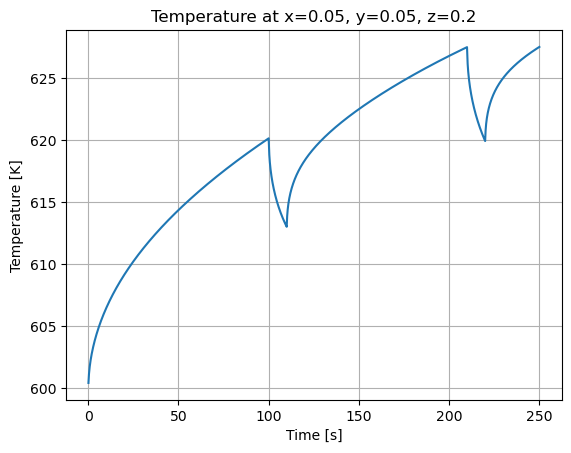

[output:8]

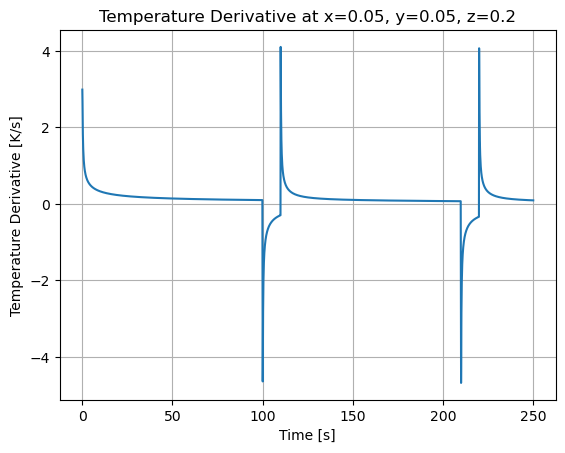

In [23]:
%%px

if rank_contains_cellid == MPI.COMM_WORLD.Get_rank():
    #plot the temperature curve of T_tracker
    plt.figure()
    plt.plot(Tracker_time[:n_i], T_tracker[:n_i])
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature [K]")
    plt.title("Temperature at x=0.05, y=0.05, z=0.2")
    plt.grid()
    plt.savefig("output/figs_noprecompileCrankNicolson0201.png")
    plt.show()

    T_tracker_derivative = np.gradient(T_tracker[:n_i], Tracker_time[:n_i])
    plt.figure()
    plt.plot(Tracker_time[:n_i], T_tracker_derivative)
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature Derivative [K/s]")
    plt.title("Temperature Derivative at x=0.05, y=0.05, z=0.2")
    plt.grid()
    plt.savefig("output/figsderiv_noprecompileCrankNicolson0201.png")
    plt.show()



In [506]:
plotter.close()

In [23]:
import pyvista
from dolfinx.plot import vtk_mesh

# Get VTK-compatible mesh and cell type
grid = pyvista.UnstructuredGrid(*vtk_mesh(msh, msh.topology.dim))

# Add solution values to the grid
grid.point_data["Temperature"] = T_n.x.array.real

# Plot
plotter = pyvista.Plotter()
plotter.add_mesh(grid, scalars="Temperature", cmap="coolwarm", show_edges=True)
plotter.add_scalar_bar("Temperature")
plotter.show()


Widget(value='<iframe src="http://localhost:41693/index.html?ui=P_0x7fa9145d6e90_0&reconnect=auto" class="pyvi…

In [24]:
import pyvista
from dolfinx.plot import vtk_mesh

# Visualize solution
pyvista.start_xvfb()
pyvista_cells, cell_types, geometry = vtk_mesh(V)
grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)
grid.point_data["u"] = uh.x.array
grid.set_active_scalars("u")

plotter = pyvista.Plotter()
plotter.add_text("uh", position="upper_edge", font_size=14, color="black")
plotter.add_mesh(grid, show_edges=True)
plotter.view_xy()
plotter.show()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    figure = plotter.screenshot("robin_neumann_dirichlet.png")

Widget(value='<iframe src="http://localhost:41693/index.html?ui=P_0x7fa9145d60d0_1&reconnect=auto" class="pyvi…

In [40]:
import numpy as np

# Get the coordinates of the mesh points
coordinates = msh.geometry.x

# Find the indices of points where y = 0.5 (with a tolerance for floating-point comparisons)
y_target = 0.5
tolerance = 1e-6
indices = np.where(np.abs(coordinates[:, 1] - y_target) < tolerance)[0]

# Extract the x and z coordinates of these points
x_coords = coordinates[indices, 0]
z_coords = coordinates[indices, 2]

# Extract the solution values at these points
solution_values = uh.x.array[indices]

# Combine x, z, and solution values for visualization
xz_plane = np.column_stack((x_coords, z_coords, solution_values))

# Sort by x and z for better visualization
xz_plane = xz_plane[np.lexsort((xz_plane[:, 1], xz_plane[:, 0]))]

# Print or process the reshaped solution
print("x-z plane at y=0.5 (x, z, solution):")
print(xz_plane)

x-z plane at y=0.5 (x, z, solution):
[[ 0.          0.          0.        ]
 [ 0.          0.1         1.07917582]
 [ 0.          0.2         2.1589054 ]
 [ 0.          0.3         3.2394006 ]
 [ 0.          0.4         4.32036669]
 [ 0.          0.5         5.40105941]
 [ 0.          0.6         6.48048102]
 [ 0.          0.7         7.55758477]
 [ 0.          0.8         8.63141242]
 [ 0.          0.9         9.70115539]
 [ 0.          1.         10.76616475]
 [ 0.          1.1        11.82593614]
 [ 0.          1.2        12.88008588]
 [ 0.          1.3        13.92832642]
 [ 0.          1.4        14.97044469]
 [ 0.          1.5        16.00628442]
 [ 0.          1.6        17.03573229]
 [ 0.          1.7        18.05870753]
 [ 0.          1.8        19.07515419]
 [ 0.          1.9        20.08503582]
 [ 0.          2.         21.08833191]
 [ 0.1         0.          0.        ]
 [ 0.1         0.1         1.08060214]
 [ 0.1         0.2         2.16169408]
 [ 0.1         0.3         

In [10]:
# We now find the degrees-of-freedom that are associated with the
# boundary facets using {py:func}`locate_dofs_topological
# <dolfinx.fem.locate_dofs_topological>`:

dofs = fem.locate_dofs_topological(V=V, entity_dim=2, entities=facets_heatplate)

In [ ]:
# and use {py:func}`dirichletbc <dolfinx.fem.dirichletbc>` to create a
# {py:class}`DirichletBC <dolfinx.fem.DirichletBC>` class that
# represents the boundary condition:

bc_heatplate = fem.dirichletbc(value=ScalarType(300), dofs=dofs, V=V)

In [ ]:
from ufl import (FacetNormal, Measure, SpatialCoordinate, TestFunction, TrialFunction, 
                 div, dot, dx, grad, inner, lhs, rhs)
from dolfinx.mesh import create_unit_square, locate_entities, meshtags

fdim = mesh.topology.dim - 1

facet_tag = meshtags(mesh, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets])

ds = Measure("ds", domain=mesh, subdomain_data=facet_tag)

In [ ]:
# +
#problem = LinearProblem(a, L, bcs=[bc], petsc_options={"ksp_type": "preonly", "pc_type": "lu"})
start_time=time.time()
problem = LinearProblem(a, L, bcs=[bc], petsc_options={"ksp_type": "preonly", "pc_type": "jacobi", "ksp_rtol": 1e-6}) # jacobi is faster (2x) than lu (for 2d); over 100x for 3d! (0.13s vs 24s). fastest: ilu preonly, kaczmarz preonly, jacobi preonly
end_time=time.time()
print("Time taken for problem setup in ms: ", (end_time-start_time)*1000)
start_time=time.time()
uh = problem.solve()
end_time=time.time()
print("Time taken to solve the problem in ms: ", (end_time-start_time)*1000)
#print number of degrees of freedom
print("Number of degrees of freedom: ", problem.A.getSize()[0])
# -

Time taken for problem setup in ms:  3408.7445735931396
Time taken to solve the problem in ms:  63202.260971069336
Number of degrees of freedom:  8120601


Results: 
200x200x200: setup time: 4s 
solvers time: 
    jacobi preonly: 63s 
    ilu preonly: 65s 
    kaczmarz preonly: 64s
    gamg preonly: 102s 

    


In [ ]:
# -
with io.VTKFile(msh.comm, "out_poisson/poisson.vtk", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)
# -

In [9]:
# +
try:
    import pyvista

    cells, types, x = plot.vtk_mesh(V)
    grid = pyvista.UnstructuredGrid(cells, types, x)
    grid.point_data["u"] = uh.x.array.real
    grid.set_active_scalars("u")
    plotter = pyvista.Plotter()
    #plotter.add_mesh(grid, show_edges=True)
    #warped = grid.warp_by_scalar()
    #plotter.add_mesh(warped)
    plotter.add_mesh(grid)
    plotter.show()
    if pyvista.OFF_SCREEN:
        print("Rendering off screen")
        pyvista.start_xvfb(wait=0.1)
        plotter.screenshot("uh_poisson.png")
    else:
        plotter.show()
except ModuleNotFoundError:
    print("'pyvista' is required to visualise the solution.")
    print("To install pyvista with pip: 'python3 -m pip install pyvista'.")
# -

Widget(value='<iframe src="http://localhost:36187/index.html?ui=P_0x7fd58358bcb0_0&reconnect=auto" class="pyvi…

Rendering off screen
